In [1]:
import os
import time
import copy
import json
import random
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.64 GB


In [23]:
class Config:
    # Paths
    DATA_DIR = Path("/content/drive/MyDrive/Cellula/WaterSegmentation/data")
    IMAGES_DIR = DATA_DIR / "images"
    LABELS_DIR = DATA_DIR / "labels"
    SAVE_DIR = DATA_DIR / "new_model_checkpoints"

    # Data
    RAW_BANDS = 12
    IMG_SIZE = 128
    CATEGORICAL_CHANNELS = [7, 10] # QA Band, ESA WorldCover

    # Features (Baseline from old best: E1_raw12_NDWI)
    USE_NDWI = True
    USE_MNDWI = False
    USE_NDMI = False

    # Model
    # Note: Increasing BASE_FILTERS from 16 to 32 increases parameters.
    # With only 306 images, monitor for overfitting. If it overfits, reduce to 16.
    BASE_FILTERS = 32
    DEPTH = 5
    DROPOUT = 0.1

    # Training
    BATCH_SIZE = 8
    EPOCHS = 100
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 20
    GRAD_CLIP = 1.0

    # Loss: Options 'bce_dice', 'bce_tversky', 'focal_dice'
    # Recommendation: Start with 'bce_dice' (closest to baseline, most stable).
    LOSS_TYPE = 'bce_dice'

    # Scheduler
    SCHEDULER = 'plateau'

    # ReduceLROnPlateau settings
    PLATEAU_FACTOR = 0.5
    PLATEAU_PATIENCE = 5
    PLATEAU_MIN_LR = 1e-7

    # Misc
    NUM_WORKERS = 2

Config.SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [24]:
def validate_pairs(images_dir, labels_dir):
    pairs = []
    for img_path in sorted(images_dir.glob("*.tif")):
        label_path = labels_dir / f"{img_path.stem}.png"
        if label_path.exists():
            pairs.append((img_path, label_path))
    return pairs

all_pairs = validate_pairs(Config.IMAGES_DIR, Config.LABELS_DIR)
print(f"Total valid pairs found: {len(all_pairs)}")

Total valid pairs found: 306


In [25]:
def has_water(label_path):
    with rasterio.open(label_path) as src:
        return int(np.any(src.read(1) == 1))

strat_labels = np.array([has_water(lbl) for _, lbl in all_pairs])
print(f"Water presence distribution: Water={np.sum(strat_labels==1)}, "
      f"No Water={np.sum(strat_labels==0)}")

# Single 80/20 stratified split
train_pairs, val_pairs, train_labels, val_labels = train_test_split(
    all_pairs,
    strat_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=strat_labels
)

# ===== Verification =====
total = len(all_pairs)
print(f"\n{'='*50}")
print(f"Total images: {total}")
print(f"Train: {len(train_pairs)} ({100*len(train_pairs)/total:.1f}%)")
print(f"Val:   {len(val_pairs)} ({100*len(val_pairs)/total:.1f}%)")
print(f"{'='*50}")

train_no_water = sum(1 for _, l in train_pairs if has_water(l) == 0)
val_no_water   = sum(1 for _, l in val_pairs   if has_water(l) == 0)

print(f"\nNo-water images per split:")
print(f"  Train: {train_no_water}")
print(f"  Val:   {val_no_water}")

assert train_no_water > 0, "No no-water images in Train!"
assert val_no_water > 0,   "No no-water images in Val!"
assert abs(len(train_pairs)/total - 0.80) < 0.03
assert abs(len(val_pairs)/total   - 0.20) < 0.03

print("\n✓ 80/20 stratified split verification passed.")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Water presence distribution: Water=261, No Water=45

Total images: 306
Train: 244 (79.7%)
Val:   62 (20.3%)


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)



No-water images per split:
  Train: 36
  Val:   9

✓ 80/20 stratified split verification passed.


In [26]:
def compute_ndwi_from_raw(img_path):
    """Load raw bands, compute NDWI from raw Green/NIR. No normalization."""
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float64)
    green = img[2]
    nir = img[4]
    ndwi = (green - nir) / (green + nir + 1e-6)
    return ndwi.astype(np.float32)


def evaluate_ndwi_threshold(pairs, threshold):
    """
    Evaluate a fixed NDWI threshold over a set of pairs.
    Returns pixel-accumulated metrics (global) and per-image stats.
    """
    eps = 1e-8
    tp = fp = fn = tn = 0
    per_image_records = []

    for img_path, mask_path in pairs:
        ndwi = compute_ndwi_from_raw(img_path)
        pred = (ndwi > threshold).astype(np.uint8)

        with rasterio.open(mask_path) as src:
            gt = (src.read(1) > 0).astype(np.uint8)

        # Accumulate global
        tp += int(((pred == 1) & (gt == 1)).sum())
        fp += int(((pred == 1) & (gt == 0)).sum())
        fn += int(((pred == 0) & (gt == 1)).sum())
        tn += int(((pred == 0) & (gt == 0)).sum())

        # Per-image (only for images with GT water)
        gt_has_water = gt.sum() > 0
        pred_has_water = pred.sum() > 0

        if gt_has_water:
            i_tp = int(((pred == 1) & (gt == 1)).sum())
            i_fp = int(((pred == 1) & (gt == 0)).sum())
            i_fn = int(((pred == 0) & (gt == 1)).sum())
            i_iou = i_tp / (i_tp + i_fp + i_fn + eps)
            i_prec = i_tp / (i_tp + i_fp + eps)
            i_rec = i_tp / (i_tp + i_fn + eps)
            i_f1 = 2 * i_prec * i_rec / (i_prec + i_rec + eps)
        else:
            # GT has no water: report separately, do not compute IoU
            i_iou = i_prec = i_rec = i_f1 = np.nan

        per_image_records.append({
            "gt_has_water": int(gt_has_water),
            "pred_has_water": int(pred_has_water),
            "iou": i_iou, "f1": i_f1, "precision": i_prec, "recall": i_rec,
            "no_water_correct": int((not gt_has_water) and (not pred_has_water)),
            "no_water_false_positive": int((not gt_has_water) and pred_has_water),
        })

    # Global metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    iou = tp / (tp + fp + fn + eps)

    return {
        "global_accuracy": accuracy,
        "global_precision": precision,
        "global_recall": recall,
        "global_f1": f1,
        "global_iou": iou,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
        "per_image_df": pd.DataFrame(per_image_records),
    }

In [27]:
ndwi_thresholds = [-0.5, -0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]

val_results = []
for thr in ndwi_thresholds:
    res = evaluate_ndwi_threshold(val_pairs, thr)
    val_results.append({
        "threshold": thr,
        "val_iou": res["global_iou"],
        "val_f1": res["global_f1"],
        "val_precision": res["global_precision"],
        "val_recall": res["global_recall"],
        "val_accuracy": res["global_accuracy"],
    })

val_df = pd.DataFrame(val_results)
print("NDWI Threshold Sweep on Validation Set:")
display(val_df)

# Select best threshold based on Validation IoU
best_ndwi_row = val_df.loc[val_df["val_iou"].idxmax()]
best_ndwi_thr = best_ndwi_row["threshold"]
print(f"\nBest NDWI threshold (by Val IoU): {best_ndwi_thr}")
print(f"  Val IoU: {best_ndwi_row['val_iou']:.4f}")
print(f"  Val F1:  {best_ndwi_row['val_f1']:.4f}")
print(f"  Val P:   {best_ndwi_row['val_precision']:.4f}")
print(f"  Val R:   {best_ndwi_row['val_recall']:.4f}")


NDWI Threshold Sweep on Validation Set:


,threshold,val_iou,val_f1,val_precision,val_recall,val_accuracy
0,-0.5,0.383750,0.554652,0.394936,0.931265,0.623484
1,-0.4,0.481577,0.650087,0.527116,0.847894,0.770194
2,-0.3,0.600634,0.750495,0.785883,0.718157,0.879778
3,-0.2,0.624421,0.768792,0.930551,0.654943,0.900819
4,-0.1,0.604061,0.753165,0.951317,0.623330,0.897135
5,0.0,0.577812,0.732422,0.960870,0.591736,0.891145
6,0.1,0.534300,0.696474,0.964817,0.544917,0.880421
7,0.2,0.484526,0.652769,0.968125,0.492381,0.868116
8,0.3,0.410272,0.581834,0.970025,0.415540,0.849618
9,0.4,0.222952,0.364613,0.960891,0.224994,0.802572



Best NDWI threshold (by Val IoU): -0.2
  Val IoU: 0.6244
  Val F1:  0.7688
  Val P:   0.9306
  Val R:   0.6549


In [28]:
val_res_ndwi = evaluate_ndwi_threshold(val_pairs, best_ndwi_thr)

print(f"NDWI Baseline on Validation Set (threshold = {best_ndwi_thr}):")
print(f"  Val IoU:       {val_res_ndwi['global_iou']:.4f}")
print(f"  Val F1:        {val_res_ndwi['global_f1']:.4f}")
print(f"  Val Precision: {val_res_ndwi['global_precision']:.4f}")
print(f"  Val Recall:    {val_res_ndwi['global_recall']:.4f}")
print(f"  Val Accuracy:  {val_res_ndwi['global_accuracy']:.4f}")

val_per_image = val_res_ndwi["per_image_df"]
n_no_water         = (val_per_image["gt_has_water"] == 0).sum()
n_no_water_correct = val_per_image["no_water_correct"].sum()
n_no_water_fp      = val_per_image["no_water_false_positive"].sum()

print(f"\nNo-water images in Val: {n_no_water}")
print(f"  Correctly predicted as no-water: {n_no_water_correct}")
print(f"  Falsely predicted water:         {n_no_water_fp}")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


NDWI Baseline on Validation Set (threshold = -0.2):
  Val IoU:       0.6244
  Val F1:        0.7688
  Val Precision: 0.9306
  Val Recall:    0.6549
  Val Accuracy:  0.9008

No-water images in Val: 9
  Correctly predicted as no-water: 6
  Falsely predicted water:         3


In [29]:
def compute_channel_stats(pairs, categorical_channels):
    """
    Compute mean and std for the 12 raw channels ONLY using the Training Set.
    Handle -9999 values in DEM channels (indices 8, 9) by replacing them with the channel mean.
    Returns arrays of length 12.
    """
    n_ch = Config.RAW_BANDS
    sums = np.zeros(n_ch)
    sums_sq = np.zeros(n_ch)
    n_px = np.zeros(n_ch)

    # First pass: compute mean for DEM channels ignoring -9999
    dem_means = np.zeros(n_ch)
    dem_counts = np.zeros(n_ch)

    for img_path, _ in pairs:
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float64)
            for ch in [8, 9]: # MERIT DEM and Copernicus DEM
                valid_mask = img[ch] != -9999
                dem_means[ch] += img[ch][valid_mask].sum()
                dem_counts[ch] += valid_mask.sum()

    dem_means = dem_means / np.maximum(dem_counts, 1)

    # Second pass: compute stats replacing -9999 with channel mean and handling NaN/Inf
    for img_path, _ in pairs:
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float64)
            for ch in [8, 9]:
                img[ch][img[ch] == -9999] = dem_means[ch]

            for ch in range(n_ch):
                if ch in categorical_channels:
                    continue
                flat = img[ch].reshape(-1)
                # Explicitly handle NaN/Inf before computing stats
                flat = np.nan_to_num(flat, nan=0.0, posinf=0.0, neginf=0.0)
                sums[ch] += flat.sum()
                sums_sq[ch] += (flat**2).sum()
                n_px[ch] += flat.shape[0]

    mean = sums / n_px
    var = np.clip((sums_sq / n_px) - mean**2, 1e-12, None)
    std = np.sqrt(var)

    # Ensure categorical channels have mean=0, std=1 (unused, but safe)
    for ch in categorical_channels:
        mean[ch] = 0.0
        std[ch] = 1.0

    return mean.astype(np.float32), std.astype(np.float32)

# Compute stats ONLY on Training Set
train_mean, train_std = compute_channel_stats(train_pairs, Config.CATEGORICAL_CHANNELS)
print(f"Train Mean shape: {train_mean.shape}, Std shape: {train_std.shape}")
print("Train Mean:", train_mean)
print("Train Std:", train_std)

# Save for inference
np.save(Config.SAVE_DIR / "train_mean.npy", train_mean)
np.save(Config.SAVE_DIR / "train_std.npy", train_std)

Train Mean shape: (12,), Std shape: (12,)
Train Mean: [ 397.10104   496.92865   823.2136    971.8184   2066.915    1940.1907
 1332.9261      0.        306.97943   305.8756      0.         10.081289]
Train Std: [2.8696906e+02 3.4414981e+02 4.3445798e+02 5.8989856e+02 1.0512172e+03
 1.1786545e+03 9.4146948e+02 1.0000000e+00 5.1777997e+02 5.1990234e+02
 1.0000000e+00 2.8178495e+01]


/tmp/ipykernel_818/2762797589.py:43: RuntimeWarning: invalid value encountered in divide
  mean = sums / n_px
/tmp/ipykernel_818/2762797589.py:44: RuntimeWarning: invalid value encountered in divide
  var = np.clip((sums_sq / n_px) - mean**2, 1e-12, None)


In [30]:
def add_indices_np(img, feature_names):
    """Add NDWI, MNDWI, NDMI indices to the image array."""
    g, n, s = img[2], img[4], img[5] # Green, NIR, SWIR1
    eps = 1e-8
    feats = []
    for name in feature_names:
        if name == "NDWI": feats.append((g - n) / (g + n + eps))
        elif name == "MNDWI": feats.append((g - s) / (g + s + eps))
        elif name == "NDMI": feats.append((n - s) / (n + s + eps))

    if feats:
        idx = np.stack(feats, axis=0)
        idx = np.nan_to_num(idx, nan=0.0, posinf=0.0, neginf=0.0)
        idx = np.clip(idx, -1., 1.)
        img = np.concatenate([img, idx], axis=0)
    return img

def add_indices_torch(image, feature_names):
    """Torch version of add_indices."""
    g, n, s = image[2], image[4], image[5]
    eps = 1e-8
    feats = []
    for name in feature_names:
        if name == "NDWI": feats.append((g - n) / (g + n + eps))
        elif name == "MNDWI": feats.append((g - s) / (g + s + eps))
        elif name == "NDMI": feats.append((n - s) / (n + s + eps))

    if feats:
        idx = torch.stack(feats, dim=0)
        idx = torch.nan_to_num(idx, nan=0.0, posinf=0.0, neginf=0.0).clamp(-1., 1.)
        image = torch.cat([image, idx], dim=0)
    return image

In [31]:
class WaterSegDataset(Dataset):
    def __init__(self, pairs, mean, std, augment=False):
        self.pairs = pairs
        self.mean = torch.tensor(mean, dtype=torch.float32) # shape (12,)
        self.std = torch.tensor(std, dtype=torch.float32)   # shape (12,)
        self.augment = augment
        self.feature_names = []
        if Config.USE_NDWI: self.feature_names.append("NDWI")
        if Config.USE_MNDWI: self.feature_names.append("MNDWI")
        if Config.USE_NDMI: self.feature_names.append("NDMI")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        with rasterio.open(img_path) as src:
            image = src.read().astype(np.float32) # (12, H, W)
            # Handle -9999 in DEM channels (8, 9)
            for ch in [8, 9]:
                mask_9999 = image[ch] == -9999
                if mask_9999.any():
                    image[ch][mask_9999] = self.mean[ch].item()

        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32) # (H, W)

        # Convert to tensor
        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask).unsqueeze(0) # (1, H, W)

        # Add features (NDWI, etc.) -> shape (12 + num_features, H, W)
        image = add_indices_torch(image, self.feature_names)

        # Normalize ONLY the first 12 raw channels (exclude categorical: 7, 10)
        # The added features (e.g., NDWI) are already in [-1, 1] and should NOT be normalized.
        for ch in range(Config.RAW_BANDS):
            if ch not in Config.CATEGORICAL_CHANNELS:
                image[ch] = (image[ch] - self.mean[ch]) / self.std[ch]

        # Data Augmentation (only for training)
        if self.augment:
            # Random Horizontal Flip
            if torch.rand(1).item() > 0.5:
                image = torch.flip(image, dims=[2])
                mask = torch.flip(mask, dims=[2])
            # Random Vertical Flip
            if torch.rand(1).item() > 0.5:
                image = torch.flip(image, dims=[1])
                mask = torch.flip(mask, dims=[1])
            # Random 90-degree rotation
            if torch.rand(1).item() > 0.5:
                k = torch.randint(1, 4, (1,)).item()
                image = torch.rot90(image, k=k, dims=[1, 2])
                mask = torch.rot90(mask, k=k, dims=[1, 2])
            # Add slight noise to continuous channels (only the raw 12)
            if torch.rand(1).item() > 0.5:
                noise = torch.randn_like(image) * 0.05
                for ch in range(Config.RAW_BANDS):
                    if ch not in Config.CATEGORICAL_CHANNELS:
                        image[ch] += noise[ch]

        return image, mask

train_dataset = WaterSegDataset(train_pairs, train_mean, train_std, augment=True)
val_dataset   = WaterSegDataset(val_pairs,   train_mean, train_std, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True
)

# Sanity check
x, y = next(iter(train_loader))
print(f"Train batch shape: {x.shape}, Mask shape: {y.shape}")
assert x.shape[1] == 12 + len(train_dataset.feature_names), "Channel mismatch!"

Train batch shape: torch.Size([8, 13, 128, 128]), Mask shape: torch.Size([8, 1, 128, 128])


In [32]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        return self.dropout(self.conv(x))

class UNet(nn.Module):
    def __init__(self, in_ch, out_ch=1, base_f=32, depth=5, dropout=0.1):
        super().__init__()
        self.depth = depth

        # Encoder
        enc_ch = [base_f * (2 ** i) for i in range(depth)]
        self.encoders = nn.ModuleList()
        c_in = in_ch
        for oc in enc_ch:
            self.encoders.append(ConvBlock(c_in, oc, dropout=dropout))
            c_in = oc

        # Bottleneck
        bn_ch = enc_ch[-1] * 2
        self.bottleneck = ConvBlock(c_in, bn_ch, dropout=dropout)

        # Decoder
        self.upconvs = nn.ModuleList()
        self.decoders = nn.ModuleList()
        f = bn_ch
        for skip_ch in reversed(enc_ch):
            up_ch = f // 2
            self.upconvs.append(nn.ConvTranspose2d(f, up_ch, kernel_size=2, stride=2))
            self.decoders.append(ConvBlock(up_ch + skip_ch, up_ch, dropout=dropout))
            f = up_ch

        self.final = nn.Conv2d(f, out_ch, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = up(x)
            x = torch.cat([x, skip], dim=1)
            x = dec(x)

        return self.final(x)

# Sanity check
in_ch = 12 + (1 if Config.USE_NDWI else 0) + (1 if Config.USE_MNDWI else 0) + (1 if Config.USE_NDMI else 0)
model = UNet(in_ch=in_ch, out_ch=1, base_f=Config.BASE_FILTERS, depth=Config.DEPTH, dropout=Config.DROPOUT).to(DEVICE)
with torch.no_grad():
    dummy = torch.randn(2, in_ch, 128, 128).to(DEVICE)
    out = model(dummy)
    print(f"Model Sanity Check: Input {dummy.shape} -> Output {out.shape}")
    assert out.shape == (2, 1, 128, 128)

Model Sanity Check: Input torch.Size([2, 13, 128, 128]) -> Output torch.Size([2, 1, 128, 128])


In [33]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1)
        t = targets.view(-1)
        inter = (p * t).sum()
        return 1.0 - (2 * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)

class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth
    def forward(self, logits, targets):
        p = torch.sigmoid(logits).view(-1)
        t = targets.view(-1)
        tp = (p * t).sum()
        fp = ((1 - t) * p).sum()
        fn = (t * (1 - p)).sum()
        return 1.0 - (tp + self.smooth) / (tp + self.alpha * fp + self.beta * fn + self.smooth)

class FocalLoss(nn.Module):
    """
    Correct Binary Focal Loss implementation.
    Supports pos_weight for class imbalance.
    """
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        # Use BCE with pos_weight as the base loss
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, reduction='none', pos_weight=self.pos_weight
        )
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

def compute_pos_weight(pairs):
    t, b = 0, 0
    for _, lbl in pairs:
        with rasterio.open(lbl) as s:
            m = s.read(1)
            t += int((m == 1).sum())
            b += int((m == 0).sum())
    return b / max(t, 1)

POS_WEIGHT = compute_pos_weight(train_pairs)
print(f"pos_weight (train): {POS_WEIGHT:.4f}")

def get_loss_fn(loss_type, pos_weight_val):
    pw = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)

    if loss_type == 'bce_dice':
        bce = nn.BCEWithLogitsLoss(pos_weight=pw)
        dice = DiceLoss()
        return lambda logits, targets: bce(logits, targets) + dice(logits, targets)
    elif loss_type == 'bce_tversky':
        bce = nn.BCEWithLogitsLoss(pos_weight=pw)
        tversky = TverskyLoss(alpha=0.7, beta=0.3)
        return lambda logits, targets: bce(logits, targets) + tversky(logits, targets)
    elif loss_type == 'focal_dice':
        focal = FocalLoss(alpha=0.25, gamma=2.0, pos_weight=pw)
        dice = DiceLoss()
        return lambda logits, targets: focal(logits, targets) + dice(logits, targets)
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

loss_fn = get_loss_fn(Config.LOSS_TYPE, POS_WEIGHT)

pos_weight (train): 2.8200


In [34]:
class MetricsAccumulator:
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0
        self.tn = 0

    def update(self, logits, targets):
        preds = (torch.sigmoid(logits) > self.threshold).float()
        self.tp += ((preds == 1) & (targets == 1)).sum().item()
        self.fp += ((preds == 1) & (targets == 0)).sum().item()
        self.fn += ((preds == 0) & (targets == 1)).sum().item()
        self.tn += ((preds == 0) & (targets == 0)).sum().item()

    def compute(self):
        eps = 1e-8
        iou = self.tp / (self.tp + self.fp + self.fn + eps)
        precision = self.tp / (self.tp + self.fp + eps)
        recall = self.tp / (self.tp + self.fn + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        accuracy = (self.tp + self.tn) / (self.tp + self.tn + self.fp + self.fn + eps)
        return {
            'iou': iou, 'f1': f1, 'precision': precision,
            'recall': recall, 'accuracy': accuracy
        }

def train_one_epoch(model, loader, optimizer, loss_fn, scaler, device):
    model.train()
    total_loss = 0.0
    metrics = MetricsAccumulator()

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with autocast(enabled=(device.type == 'cuda')):
            logits = model(x)
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), Config.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * x.size(0)
        metrics.update(logits.detach(), y.detach())

    return total_loss / len(loader.dataset), metrics.compute()

@torch.no_grad()
def evaluate(model, loader, loss_fn, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    metrics = MetricsAccumulator(threshold=threshold)

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        with autocast(enabled=(device.type == 'cuda')):
            logits = model(x)
            loss = loss_fn(logits, y)

        total_loss += loss.item() * x.size(0)
        metrics.update(logits, y)

    return total_loss / len(loader.dataset), metrics.compute()

In [35]:
def run_training():
    set_seed(SEED)

    # Model
    model = UNet(in_ch=in_ch, out_ch=1, base_f=Config.BASE_FILTERS,
                 depth=Config.DEPTH, dropout=Config.DROPOUT).to(DEVICE)

    # Optimizer
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY
    )

    # Scheduler
    if Config.SCHEDULER == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=Config.EPOCHS, eta_min=1e-6)
    elif Config.SCHEDULER == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=Config.PLATEAU_FACTOR,
            patience=Config.PLATEAU_PATIENCE,
            min_lr=Config.PLATEAU_MIN_LR
        )
    else:
        raise ValueError(f"Unknown scheduler: {Config.SCHEDULER}")

    # Scaler & Loss
    scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))
    loss_fn = get_loss_fn(Config.LOSS_TYPE, POS_WEIGHT)

    best_val_iou = -float('inf')
    best_epoch = 0
    best_state = None
    no_improve = 0
    history = []

    print(f"Starting training for {Config.EPOCHS} epochs with {Config.LOSS_TYPE} loss...")
    print(f"Scheduler: {Config.SCHEDULER}")
    if Config.PATIENCE is None:
        print("⚠️  Early Stopping is DISABLED — training will run all epochs.")
    else:
        print(f"Early Stopping enabled with patience={Config.PATIENCE}.")

    t0 = time.time()

    for epoch in range(1, Config.EPOCHS + 1):
        tr_loss, tr_metrics = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler, DEVICE)
        vl_loss, vl_metrics = evaluate(model, val_loader, loss_fn, DEVICE, threshold=0.5)

        # Update scheduler
        if Config.SCHEDULER == 'cosine':
            scheduler.step()
        elif Config.SCHEDULER == 'plateau':
            scheduler.step(vl_metrics['iou'])

        history.append({
            'epoch': epoch,
            'train_loss': tr_loss,
            'val_loss': vl_loss,
            'lr': optimizer.param_groups[0]["lr"],
            **{f'val_{k}': v for k, v in vl_metrics.items()}
        })

        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Ep {epoch:03d} | Tr Loss: {tr_loss:.4f} | Vl Loss: {vl_loss:.4f} | "
              f"Vl IoU: {vl_metrics['iou']:.4f} | Vl F1: {vl_metrics['f1']:.4f} | "
              f"P: {vl_metrics['precision']:.4f} | R: {vl_metrics['recall']:.4f} | "
              f"LR: {current_lr:.7f}")

        # Save best model
        if vl_metrics['iou'] > best_val_iou:
            best_val_iou = vl_metrics['iou']
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
            torch.save(best_state, Config.SAVE_DIR / "best_model.pth")
            print(f"  -> New best model saved! (Val IoU @ 0.5: {best_val_iou:.4f})")
        else:
            no_improve += 1
            # Early stopping disabled (PATIENCE=None)
            if Config.PATIENCE is not None and no_improve >= Config.PATIENCE:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    train_time = time.time() - t0
    print(f"\nTraining completed in {train_time/60:.2f} minutes.")
    print(f"Best Val IoU @ 0.5: {best_val_iou:.4f} at epoch {best_epoch}")

    return history, best_state, best_epoch, best_val_iou, train_time

history, best_state, best_epoch, best_val_iou, train_time = run_training()

Starting training for 100 epochs with bce_dice loss...
Scheduler: plateau
Early Stopping enabled with patience=20.


/tmp/ipykernel_818/2687735261.py:28: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE.type == 'cuda'))
/tmp/ipykernel_818/519028514.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):
/tmp/ipykernel_818/519028514.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


Ep 001 | Tr Loss: 1.4625 | Vl Loss: 1.3134 | Vl IoU: 0.4871 | Vl F1: 0.6551 | P: 0.6261 | R: 0.6868 | LR: 0.0001000
  -> New best model saved! (Val IoU @ 0.5: 0.4871)
Ep 002 | Tr Loss: 1.3018 | Vl Loss: 1.1636 | Vl IoU: 0.5007 | Vl F1: 0.6673 | P: 0.6254 | R: 0.7152 | LR: 0.0001000
  -> New best model saved! (Val IoU @ 0.5: 0.5007)
Ep 003 | Tr Loss: 1.2204 | Vl Loss: 1.0842 | Vl IoU: 0.5417 | Vl F1: 0.7027 | P: 0.6396 | R: 0.7797 | LR: 0.0001000
  -> New best model saved! (Val IoU @ 0.5: 0.5417)
Ep 004 | Tr Loss: 1.1839 | Vl Loss: 1.1477 | Vl IoU: 0.5020 | Vl F1: 0.6684 | P: 0.5474 | R: 0.8580 | LR: 0.0001000
Ep 005 | Tr Loss: 1.1260 | Vl Loss: 1.0489 | Vl IoU: 0.5802 | Vl F1: 0.7343 | P: 0.7003 | R: 0.7718 | LR: 0.0001000
  -> New best model saved! (Val IoU @ 0.5: 0.5802)
Ep 006 | Tr Loss: 1.0927 | Vl Loss: 1.0024 | Vl IoU: 0.6325 | Vl F1: 0.7748 | P: 0.8156 | R: 0.7380 | LR: 0.0001000
  -> New best model saved! (Val IoU @ 0.5: 0.6325)
Ep 007 | Tr Loss: 1.0792 | Vl Loss: 0.9698 | Vl I

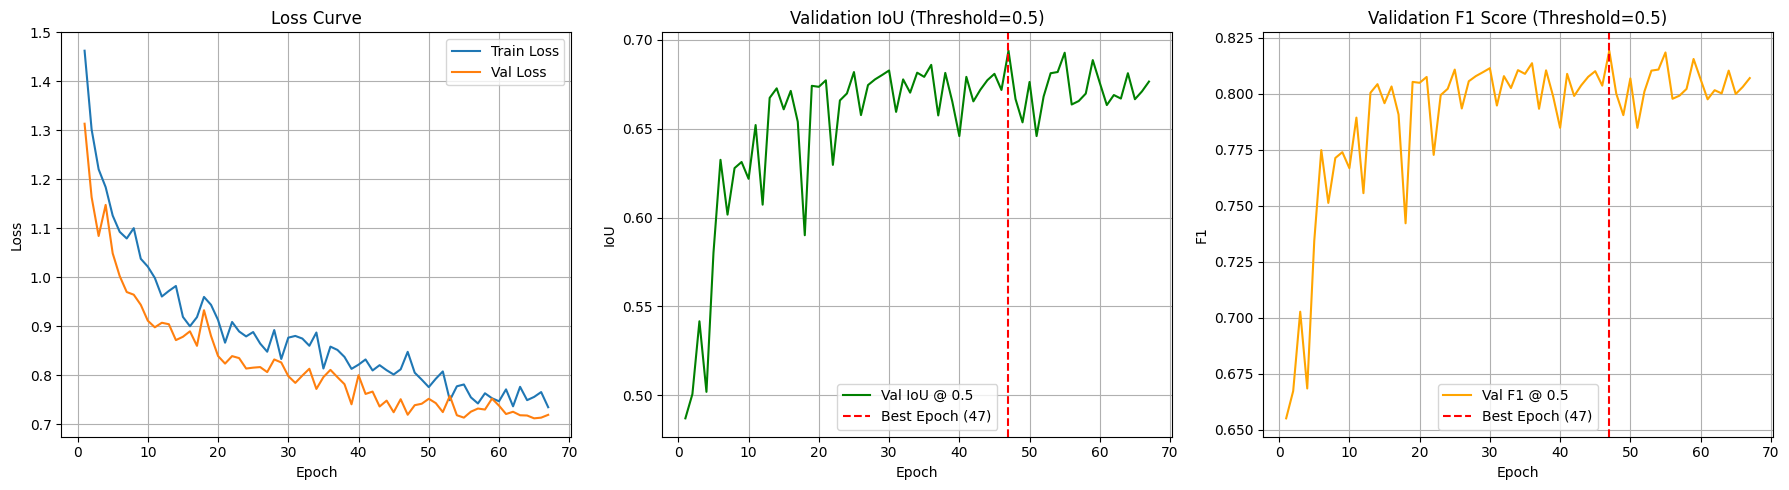

In [36]:
def plot_training_curves(history, best_epoch):
    df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(df['epoch'], df['train_loss'], label='Train Loss')
    axes[0].plot(df['epoch'], df['val_loss'], label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # IoU
    axes[1].plot(df['epoch'], df['val_iou'], label='Val IoU @ 0.5', color='green')
    axes[1].axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
    axes[1].set_title('Validation IoU (Threshold=0.5)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('IoU')
    axes[1].legend()
    axes[1].grid(True)

    # F1
    axes[2].plot(df['epoch'], df['val_f1'], label='Val F1 @ 0.5', color='orange')
    axes[2].axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
    axes[2].set_title('Validation F1 Score (Threshold=0.5)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history, best_epoch)

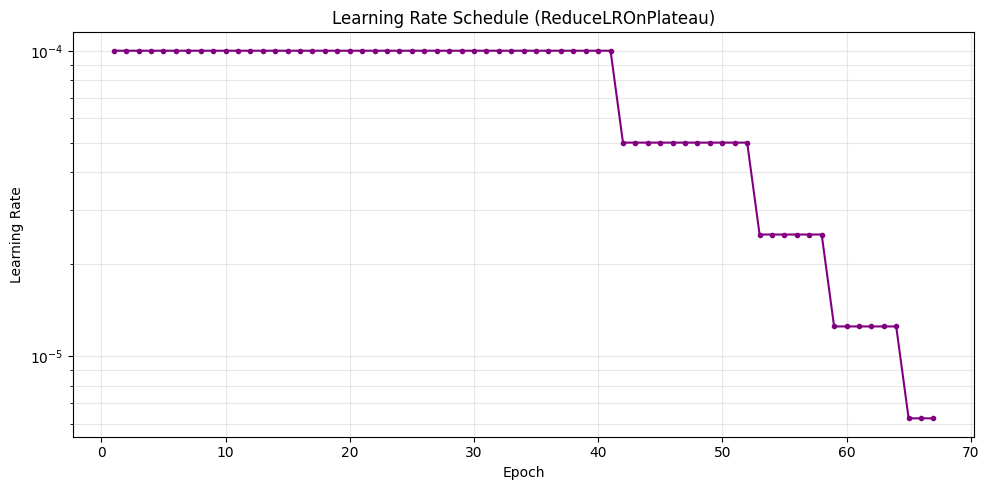

Learning Rate changes:
 epoch       lr  val_iou
     1 0.000100 0.487079
    42 0.000050 0.665320
    53 0.000025 0.681154
    59 0.000013 0.688536
    65 0.000006 0.666526


In [37]:
def plot_lr_schedule(history):
    df = pd.DataFrame(history)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(df['epoch'], df['lr'], marker='o', markersize=3, color='purple')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule (ReduceLROnPlateau)')
    ax.set_yscale('log')
    ax.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # اطبع الأماكن اللي اتغير فيها الـLR
    lr_changes = df[df['lr'].diff() != 0]
    print("Learning Rate changes:")
    print(lr_changes[['epoch', 'lr', 'val_iou']].to_string(index=False))

plot_lr_schedule(history)

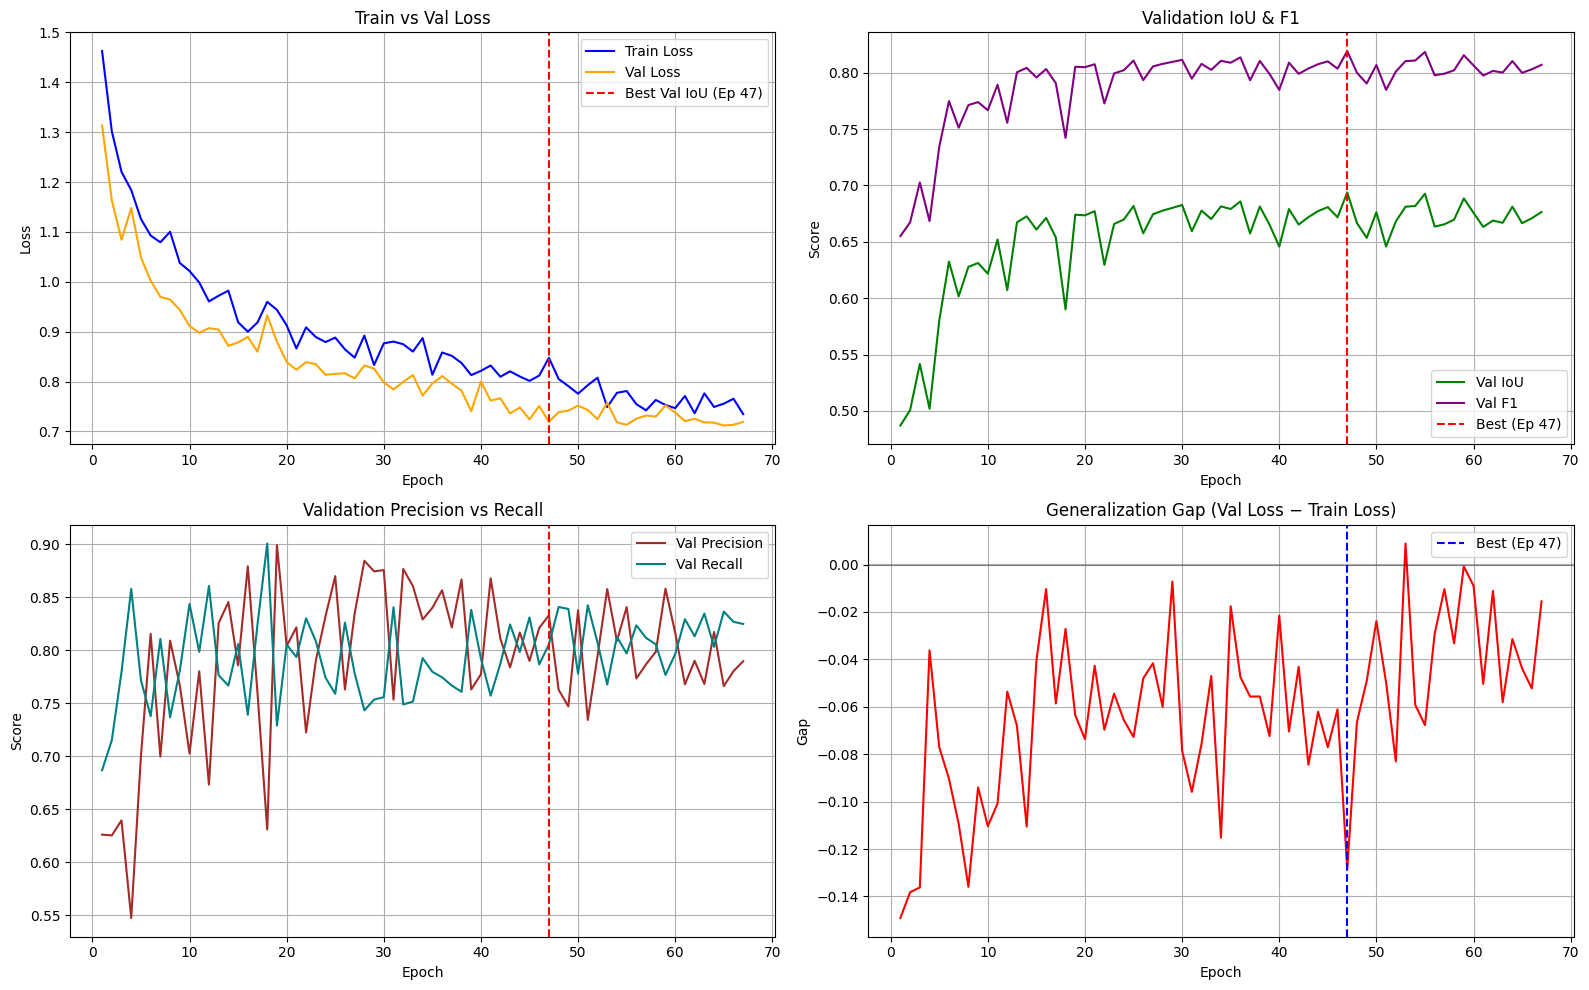


OVERFITTING DIAGNOSTIC SUMMARY
Best Val IoU:  0.6938 @ epoch 47
Final Val IoU: 0.6765 @ epoch 67
Final Train Loss: 0.7346
Final Val Loss:   0.7191
Overfitting started around epoch: 48
✓  Best epoch (47) is at 70% of training.
    → Training beyond this point is not improving Val IoU.


In [38]:
def plot_overfitting_diagnostic(history, best_epoch):
    df = pd.DataFrame(history)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Train vs Val Loss
    axes[0, 0].plot(df['epoch'], df['train_loss'], label='Train Loss', color='blue')
    axes[0, 0].plot(df['epoch'], df['val_loss'], label='Val Loss', color='orange')
    axes[0, 0].axvline(x=best_epoch, color='red', linestyle='--',
                       label=f'Best Val IoU (Ep {best_epoch})')
    axes[0, 0].set_title('Train vs Val Loss')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend(); axes[0, 0].grid(True)

    # 2. Val IoU and F1
    axes[0, 1].plot(df['epoch'], df['val_iou'], label='Val IoU', color='green')
    axes[0, 1].plot(df['epoch'], df['val_f1'], label='Val F1', color='purple')
    axes[0, 1].axvline(x=best_epoch, color='red', linestyle='--',
                       label=f'Best (Ep {best_epoch})')
    axes[0, 1].set_title('Validation IoU & F1')
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Score')
    axes[0, 1].legend(); axes[0, 1].grid(True)

    # 3. Precision vs Recall
    axes[1, 0].plot(df['epoch'], df['val_precision'], label='Val Precision', color='brown')
    axes[1, 0].plot(df['epoch'], df['val_recall'], label='Val Recall', color='teal')
    axes[1, 0].axvline(x=best_epoch, color='red', linestyle='--')
    axes[1, 0].set_title('Validation Precision vs Recall')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend(); axes[1, 0].grid(True)

    # 4. Generalization Gap (Val Loss - Train Loss)
    gap = df['val_loss'] - df['train_loss']
    axes[1, 1].plot(df['epoch'], gap, color='red')
    axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1, 1].axvline(x=best_epoch, color='blue', linestyle='--',
                       label=f'Best (Ep {best_epoch})')
    axes[1, 1].set_title('Generalization Gap (Val Loss − Train Loss)')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Gap')
    axes[1, 1].legend(); axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

    # === Print summary ===
    print("\n" + "="*60)
    print("OVERFITTING DIAGNOSTIC SUMMARY")
    print("="*60)
    print(f"Best Val IoU:  {df['val_iou'].max():.4f} @ epoch {best_epoch}")
    print(f"Final Val IoU: {df['val_iou'].iloc[-1]:.4f} @ epoch {df['epoch'].iloc[-1]}")
    print(f"Final Train Loss: {df['train_loss'].iloc[-1]:.4f}")
    print(f"Final Val Loss:   {df['val_loss'].iloc[-1]:.4f}")

    # إمتى بدأ الـOverfitting (أول epoch الـVal Loss فيه بيزيد بعد الـbest)
    post_best = df[df['epoch'] > best_epoch]
    if len(post_best) > 0:
        overfit_start = post_best[post_best['val_loss'] > df.loc[df['epoch'] == best_epoch, 'val_loss'].values[0]]
        if len(overfit_start) > 0:
            print(f"Overfitting started around epoch: {overfit_start['epoch'].iloc[0]}")
        else:
            print("No clear overfitting detected (Val Loss kept decreasing or stable).")

    # هل الـBest Epoch قريب من الآخر؟
    total_epochs = df['epoch'].iloc[-1]
    if best_epoch / total_epochs > 0.9:
        print(f"⚠️  Best epoch ({best_epoch}) is near the end ({total_epochs}).")
        print("    → Consider training longer or the model hasn't converged yet.")
    else:
        print(f"✓  Best epoch ({best_epoch}) is at {100*best_epoch/total_epochs:.0f}% of training.")
        print("    → Training beyond this point is not improving Val IoU.")

plot_overfitting_diagnostic(history , best_epoch)

In [39]:
model = UNet(in_ch=in_ch, out_ch=1, base_f=Config.BASE_FILTERS, depth=Config.DEPTH, dropout=Config.DROPOUT).to(DEVICE)
model.load_state_dict(torch.load(Config.SAVE_DIR / "best_model.pth"))
model.eval()
print("Best model loaded successfully.")


Best model loaded successfully.


In [40]:
@torch.no_grad()
def evaluate_thresholds(model, loader, device, thresholds):
    model.eval()
    all_logits = []
    all_targets = []

    for x, y in loader:
        x = x.to(device)
        with autocast(enabled=(device.type == 'cuda')):
            logits = model(x)
        all_logits.append(logits.cpu())
        all_targets.append(y)

    all_logits = torch.cat(all_logits)
    all_targets = torch.cat(all_targets)

    results = []
    for thr in thresholds:
        metrics = MetricsAccumulator(threshold=thr)
        metrics.update(all_logits, all_targets)
        res = metrics.compute()
        res['threshold'] = thr
        results.append(res)

    return pd.DataFrame(results)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
thr_df = evaluate_thresholds(model, val_loader, DEVICE, thresholds)

print("Threshold Tuning on Validation Set:")
display(thr_df.sort_values("f1", ascending=False))

best_thr = thr_df.loc[thr_df["f1"].idxmax(), "threshold"]
print(f"Best Threshold selected (by Val F1): {best_thr}")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/tmp/ipykernel_818/2494675410.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


Threshold Tuning on Validation Set:


,iou,f1,precision,recall,accuracy,threshold
3,0.699065,0.822882,0.884011,0.769661,0.916583,0.6
4,0.694809,0.819926,0.916026,0.742075,0.917935,0.7
2,0.693808,0.819229,0.833145,0.805771,0.910470,0.5
1,0.618005,0.763910,0.662894,0.901247,0.859747,0.4
0,0.609675,0.757513,0.647525,0.912512,0.852915,0.3


Best Threshold selected (by Val F1): 0.6


In [41]:
val_loss, val_metrics = evaluate(
    model, val_loader, loss_fn, DEVICE, threshold=best_thr
)

print(f"Validation Loss:      {val_loss:.4f}")
print(f"Validation IoU:       {val_metrics['iou']:.4f}")
print(f"Validation F1:        {val_metrics['f1']:.4f}")
print(f"Validation Precision: {val_metrics['precision']:.4f}")
print(f"Validation Recall:    {val_metrics['recall']:.4f}")
print(f"Validation Accuracy:  {val_metrics['accuracy']:.4f}")

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/tmp/ipykernel_818/519028514.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


Validation Loss:      0.7192
Validation IoU:       0.6991
Validation F1:        0.8229
Validation Precision: 0.8840
Validation Recall:    0.7697
Validation Accuracy:  0.9166


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/tmp/ipykernel_818/3692168485.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == "cuda")):



--- Final Validation Metrics (single evaluation) ---
Validation iou: 0.6991
Validation f1: 0.8229
Validation precision: 0.8840
Validation recall: 0.7697
Validation accuracy: 0.9166


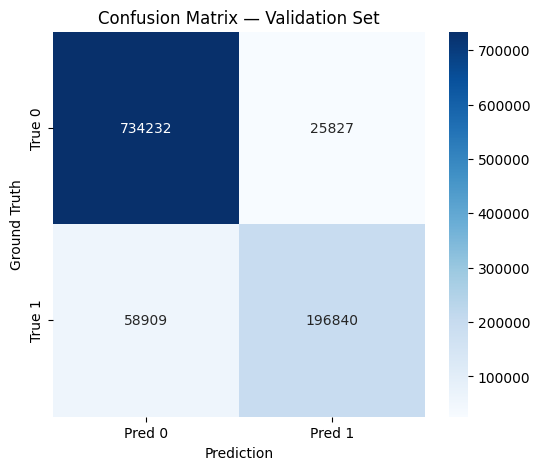

In [42]:
metrics_acc = MetricsAccumulator(threshold=best_thr)

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        with autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(x)
        metrics_acc.update(logits, y)

val_res = metrics_acc.compute()

print("\n--- Final Validation Metrics (single evaluation) ---")
for k in ["iou", "f1", "precision", "recall", "accuracy"]:
    print(f"Validation {k}: {val_res[k]:.4f}")

cm = np.array([[metrics_acc.tn, metrics_acc.fp],
               [metrics_acc.fn, metrics_acc.tp]])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
plt.title("Confusion Matrix — Validation Set")
plt.ylabel("Ground Truth")
plt.xlabel("Prediction")
plt.show()

In [43]:
comparison = pd.DataFrame([
    {
        "Method": "Classical NDWI",
        "Best Val Threshold": best_ndwi_thr,
        "Val IoU": best_ndwi_row["val_iou"],
        "Val F1":  best_ndwi_row["val_f1"],
    },
    {
        "Method": "U-Net (Deep Learning)",
        "Best Val Threshold": best_thr,
        "Val IoU": val_res["iou"],
        "Val F1":  val_res["f1"],
    },
])

display(comparison)

,Method,Best Val Threshold,Val IoU,Val F1
0,Classical NDWI,-0.2,0.624421,0.768792
1,U-Net (Deep Learning),0.6,0.699065,0.822882


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/tmp/ipykernel_818/298107912.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device.type == 'cuda')):


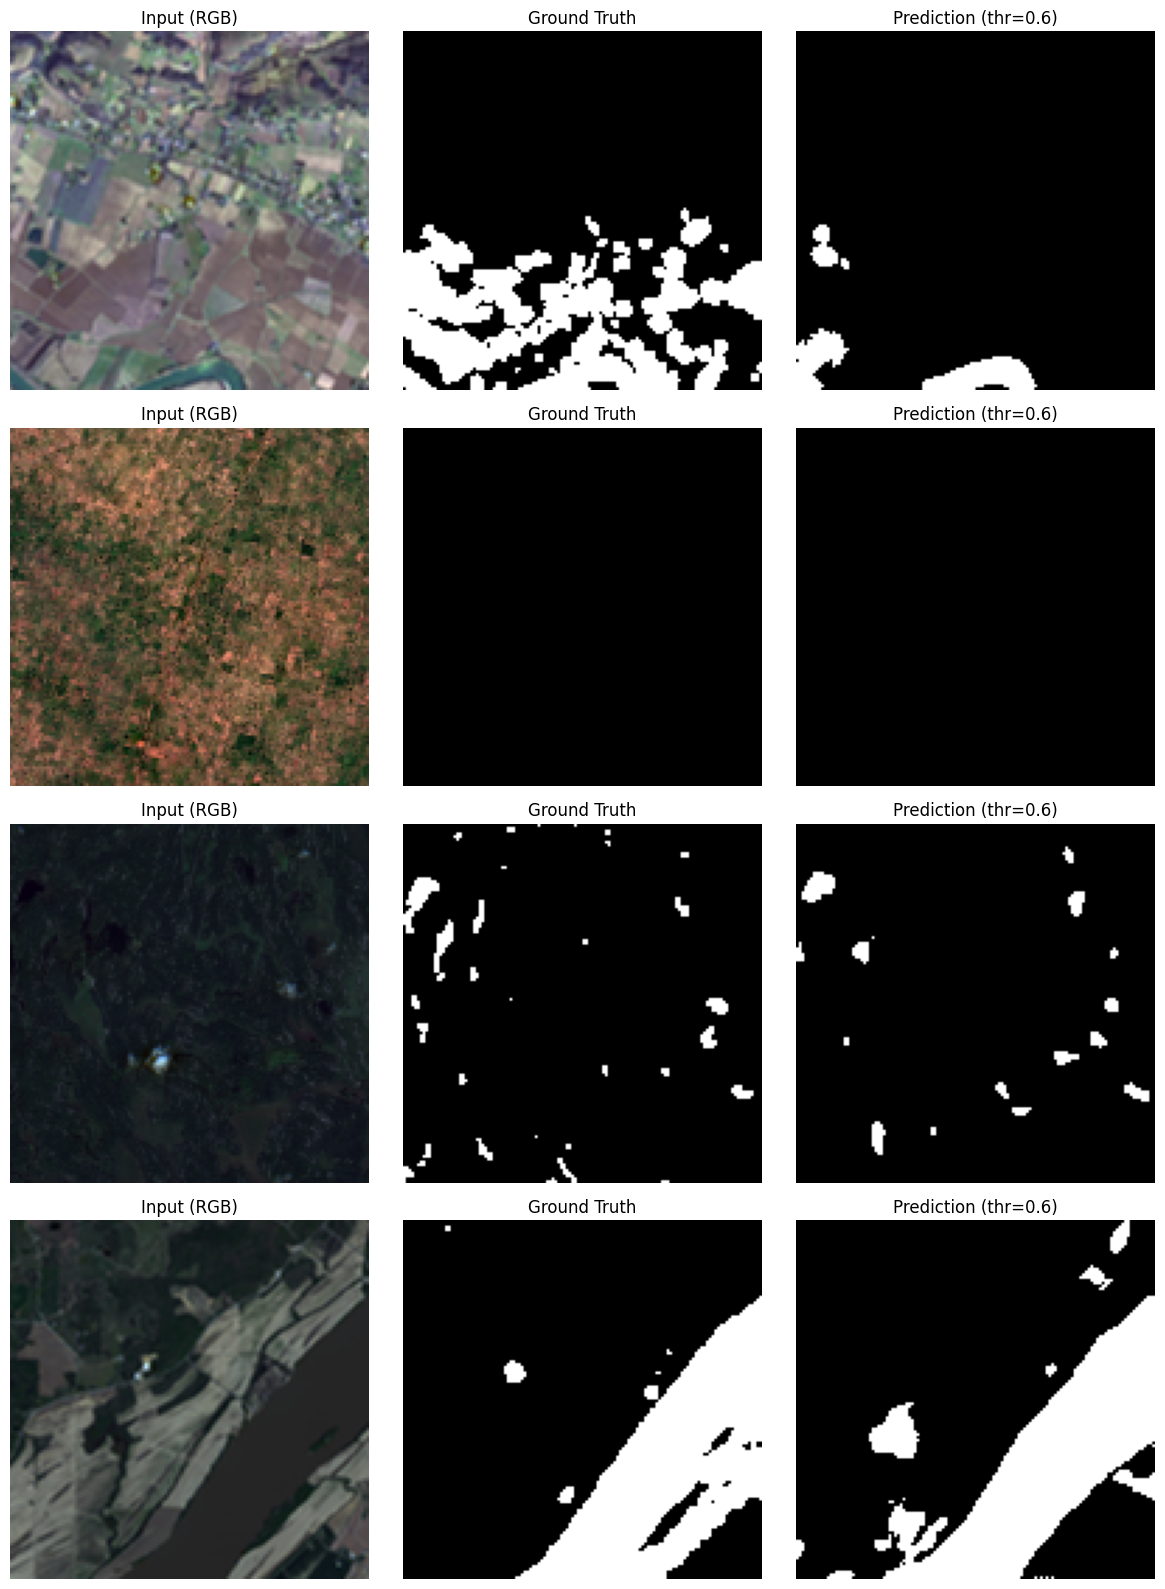

In [44]:
def visualize_predictions(model, loader, device, threshold, num_samples=4):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    samples_shown = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with autocast(enabled=(device.type == 'cuda')):
                logits = model(x)
            preds = (torch.sigmoid(logits) > threshold).float()

            for i in range(x.size(0)):
                if samples_shown >= num_samples:
                    break

                # Use RGB channels for visualization (Red=3, Green=2, Blue=1)
                rgb = x[i, [3, 2, 1]].cpu().numpy().transpose(1, 2, 0)
                # Normalize RGB for display
                rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

                gt = y[i, 0].cpu().numpy()
                pred = preds[i, 0].cpu().numpy()

                axes[samples_shown, 0].imshow(rgb)
                axes[samples_shown, 0].set_title('Input (RGB)')
                axes[samples_shown, 0].axis('off')

                axes[samples_shown, 1].imshow(gt, cmap='gray')
                axes[samples_shown, 1].set_title('Ground Truth')
                axes[samples_shown, 1].axis('off')

                axes[samples_shown, 2].imshow(pred, cmap='gray')
                axes[samples_shown, 2].set_title(f'Prediction (thr={threshold})')
                axes[samples_shown, 2].axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader, DEVICE, best_thr, num_samples=4)

In [45]:
print("\n" + "=" * 60)
print("FINAL VALIDATION SUMMARY (80/20, no test set)")
print("=" * 60)
print(f"Best Epoch:           {best_epoch}")
print(f"Best Threshold:       {best_thr}")
print(f"Validation Loss:      {val_loss:.4f}")
print(f"Validation IoU:       {val_metrics['iou']:.4f}")
print(f"Validation F1:        {val_metrics['f1']:.4f}")
print(f"Validation Precision: {val_metrics['precision']:.4f}")
print(f"Validation Recall:    {val_metrics['recall']:.4f}")
print(f"Validation Accuracy:  {val_metrics['accuracy']:.4f}")
print("=" * 60)
print("Note: Threshold was tuned on this Validation set.")
print("No independent test set was used in this experiment.")
print("=" * 60)


FINAL VALIDATION SUMMARY (80/20, no test set)
Best Epoch:           47
Best Threshold:       0.6
Validation Loss:      0.7192
Validation IoU:       0.6991
Validation F1:        0.8229
Validation Precision: 0.8840
Validation Recall:    0.7697
Validation Accuracy:  0.9166
Note: Threshold was tuned on this Validation set.
No independent test set was used in this experiment.
